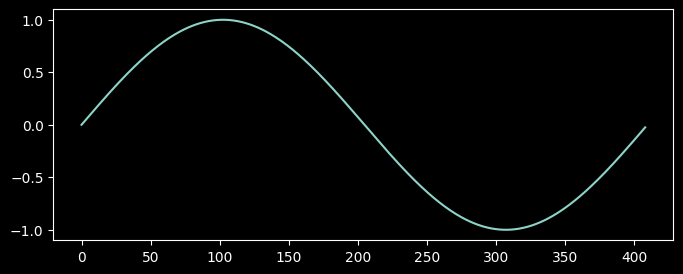

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio, display

plt.style.use('dark_background')

fs = 44100
N = 2048
freq = 5 * fs / N

t = np.arange(N) / fs
signal = np.sin(2 * np.pi * freq * t)

plt.figure(figsize=(8,3))
plt.plot(signal[:len(signal)//5])
plt.show()

display(Audio(np.tile(signal, 20), rate=fs))

In [545]:
from sympy import primerange
fs = 44100
N = 2048
phase = np.arange(N) / N

def linear(modes, damping):
    wave = np.zeros(N)
    for n in range(1, modes+1):
        harmonic = n
        amp = np.exp(-n*damping)
        wave += amp * np.sin(2*np.pi*harmonic*phase)
    return wave

def odd(modes, damping):
    wave = np.zeros(N)
    for n in range(1, modes+1):
        harmonic = n*2-1
        amp = np.exp(-n*damping)
        wave += amp * np.sin(2*np.pi*harmonic*phase)
    return wave

def prime(modes, damping):
    wave = np.zeros(N)
    primes = list(primerange(1, 1000))[:modes]  # first `modes` primes
    for n, harmonic in enumerate(primes, 1):
        amp = np.exp(-n*damping)
        wave += amp * np.sin(2*np.pi*harmonic*phase)
    return wave

def square(modes, damping):
    wave = np.zeros(N)
    for n in range(1, modes+1):
        harmonic = n**2
        amp = np.exp(-n*damping)
        wave += amp * np.sin(2*np.pi*harmonic*phase)
    return wave

def alt(modes, damping):
    wave = np.zeros(N)
    for n in range(1, modes+1):
        harmonic = n if n%2 else n*2
        amp = np.exp(-n*damping)
        wave += amp * np.sin(2*np.pi*harmonic*phase)
    return wave

def exp(modes, damping):
    wave = np.zeros(N)
    for n in range(1, modes+1):
        harmonic = 2**(n-1)
        amp = np.exp(-n*damping)
        wave += amp * np.sin(2*np.pi*harmonic*phase)
    return wave

def tri(modes, damping):
    wave = np.zeros(N)
    for n in range(1, modes+1):
        harmonic = (n**2 + n) * 0.5
        amp = np.exp(-n*damping)
        wave += amp * np.sin(2*np.pi*harmonic*phase)
    return wave


def penta(modes, damping):
    wave = np.zeros(N)
    for n in range(1, modes+1):
        harmonic = (3*n**2 + n) * 0.5
        amp = np.exp(-n*damping)
        wave += amp * np.sin(2*np.pi*harmonic*phase)
    return wave

def hexa(modes, damping):
    wave = np.zeros(N)
    for n in range(1, modes+1):
        harmonic = 2*n**2 + n
        amp = np.exp(-n*damping)
        wave += amp * np.sin(2*np.pi*harmonic*phase)
    return wave


def fft_gen(modes, harmonics, damping, phases=[]):
    wave = np.zeros(N)
    Nfft = N
    bins = np.zeros(Nfft, dtype=complex)
    if len(phases) == 0:
        phases = np.zeros(modes)
    
    for n in range(1, modes+1):
        harmonic = harmonics[n-1]
        amp = np.exp(-n*damping)
        phase = phases[n-1]
        
        i_lower = int(np.floor(harmonic)) % Nfft
        i_upper = (i_lower + 1) % Nfft
        frac = harmonic - i_lower
        
        # add +pi/2 default phase to match original
        value = amp * np.exp(1j * (phase + np.pi/2))
        
        bins[i_lower] += value * (1 - frac)
        bins[i_upper] += value * frac
        
        bins[-i_lower] = np.conj(bins[i_lower])
        bins[-i_upper] = np.conj(bins[i_upper])
    
    wave = np.fft.ifft(bins).real
    wave /= np.max(np.abs(wave))
    return -wave
    

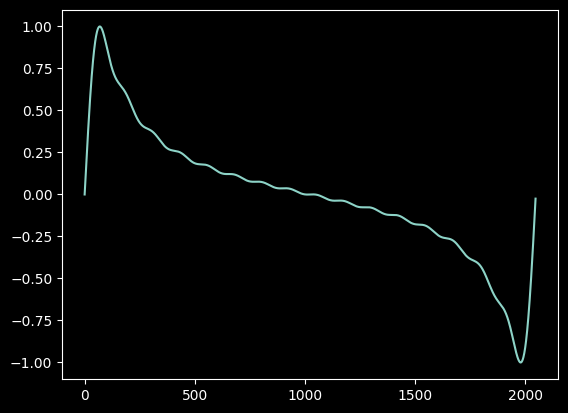

In [527]:
modes = 16

wave = linear(modes, 0.2)
wave /= np.max(np.abs(wave))

plt.plot(wave[:len(wave)])
plt.show()

display(Audio(np.tile(wave,250), rate=fs * 4))



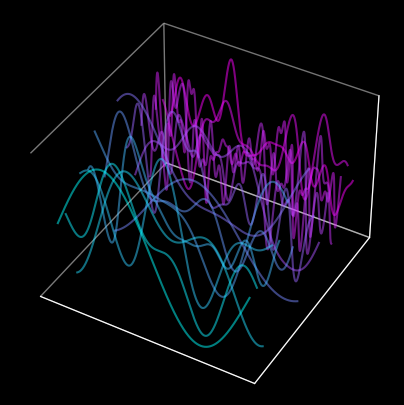

In [561]:
import os
from scipy.io import wavfile
import math

def plot_wavetable(wavetable, alpha=0.5):
    wavetable = np.array(wavetable)
    numtables = len(wavetable)

    # Colormap
    cmap = plt.get_cmap('cool')
    colors = [cmap(i) for i in np.linspace(0, 1, numtables)]

    # Prepare 3D figure
    fig = plt.figure(figsize=(5,5))
    ax = fig.add_subplot(111, projection='3d')
    ax.set_facecolor("black")
    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False
    ax.grid(False)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])

    for i in reversed(range(len(wavetable))):
        wave = wavetable[i]
        x = np.arange(len(wave))           # sample index
        y = np.full(len(wave), i * 1)      # offset along Y
        z = wave                           # amplitude
        ax.plot(x, y, z, color=colors[i], alpha=alpha)

    ax.view_init(elev=40, azim=-60)
    plt.show()

def export_wavetable(wavetables, folder, base_name, sample_rate=44100):
    os.makedirs(folder, exist_ok=True)
    wavetables = np.array(wavetables)
    wavetable_float32 = wavetables.flatten().astype(np.float32)
    wavetable_float32 /= np.max(np.abs(wavetable_float32))  # normalize [-1,1]
    filename = os.path.join(folder, f"{base_name}.wav")
    wavfile.write(filename, sample_rate, wavetable_float32)

modes = 16
waves = []
for i in range(modes):
    harmonics = np.arange(1, modes+1) * np.random.uniform(0.1, 2)
    phases = np.random.uniform(0, 2*np.pi, modes)
    phases[0] = 0
    
    wave = fft_gen(i+1, harmonics, 0.05, phases)
    wave /= np.max(np.abs(wave))
    waves.append(wave)
    
plot_wavetable(waves)

export_wavetable(waves, "./exported", "_1")